# Recreating LeNet-5 on MNIST using Nanograd

In this tutorial, we will use **Nanograd** to build and train the classic **LeNet-5** Convolutional Neural Network (CNN) architecture from scratch. We will train it on a subset of the **MNIST** database of handwritten digits.

## LeNet-5 Architecture
Originally proposed by Yann LeCun et al. in 1998, LeNet-5 is one of the earliest convolutional neural networks and helped start the deep learning revolution. Here is the structure we will implement:

| Layer | Type | Input Shape | Filter / Kernel | Padding | Stride | Output Shape |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Input** | Grayscale Image | `(N, 1, 28, 28)` | - | - | - | `(N, 1, 28, 28)` |
| **Conv 1** | Convolution 2D | `(N, 1, 28, 28)` | 6 filters of size $5\times5$ | 2 | 1 | `(N, 6, 28, 28)` |
| **Pool 1** | Max Pooling | `(N, 6, 28, 28)` | pool size $2\times2$ | 0 | 2 | `(N, 6, 14, 14)` |
| **Conv 2** | Convolution 2D | `(N, 6, 14, 14)` | 16 filters of size $5\times5$ | 0 | 1 | `(N, 16, 10, 10)` |
| **Pool 2** | Max Pooling | `(N, 16, 10, 10)` | pool size $2\times2$ | 0 | 2 | `(N, 16, 5, 5)` |
| **Flatten** | Reshape / Flatten | `(N, 16, 5, 5)` | - | - | - | `(N, 400)` |
| **FC 1** | Fully Connected | `(N, 400)` | 120 neurons | - | - | `(N, 120)` |
| **FC 2** | Fully Connected | `(N, 120)` | 84 neurons | - | - | `(N, 84)` |
| **FC 3** | Fully Connected | `(N, 84)` | 10 neurons (logits) | - | - | `(N, 10)` |

---

In [51]:
# Enable importing nanograd from parent directory
import sys
import os
sys.path.append(os.path.abspath('..'))

import gzip
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

# Import nanograd components
from nanograd import Tensor, relu
from nanograd.nn import Conv2D, MaxPool2D, Flatten, Layer
from nanograd.optim import Adam
from nanograd.loss import SoftmaxCrossEntropy

# Set random seed for reproducibility
np.random.seed(42)

## 1. Downloading and Loading MNIST Dataset

We will download the raw MNIST gzip files from a standard Google Cloud storage mirror and parse them directly into NumPy arrays using built-in Python tools. 

To ensure training runs quickly and interactively within a few seconds, we will use a small subset of MNIST (e.g. 2048 training images and 512 testing images). Since our engine runs on pure Python/NumPy, this is plenty of data to see LeNet-5 successfully learn and improve its accuracy!

In [52]:
os.makedirs('data', exist_ok=True)

urls = {
    'train_images': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz',
    'train_labels': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz',
    'test_images': 'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz',
    'test_labels': 'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz'
}

for name, url in urls.items():
    path = os.path.join('data', url.split('/')[-1])
    if not os.path.exists(path):
        print(f"Downloading {url} to {path}...")
        urllib.request.urlretrieve(url, path)
        print("Done.")
    else:
        print(f"{path} already exists.")

data/train-images-idx3-ubyte.gz already exists.
data/train-labels-idx1-ubyte.gz already exists.
data/t10k-images-idx3-ubyte.gz already exists.
data/t10k-labels-idx1-ubyte.gz already exists.


Now let's write helper functions to parse the raw byte files.

In [ ]:
def load_mnist_images(filename):
    with gzip.open(filename, 'rb') as f:
        # Read header: magic number (4 bytes), num images (4 bytes), rows (4 bytes), cols (4 bytes)
        magic, num, rows, cols = np.frombuffer(f.read(16), dtype=np.dtype('>i4'))
        # Read raw pixel values
        data = np.frombuffer(f.read(), dtype=np.uint8)
        # Reshape and normalize to range [0.0, 1.0]
        return data.reshape(num, 1, rows, cols).astype(np.float32) / 255.0

def load_mnist_labels(filename):
    with gzip.open(filename, 'rb') as f:
        # Read header: magic number (4 bytes), num labels (4 bytes)
        magic, num = np.frombuffer(f.read(8), dtype=np.dtype('>i4'))
        # Read labels
        data = np.frombuffer(f.read(), dtype=np.uint8)
        return data.astype(np.int64)

# Load full datasets
all_train_images = load_mnist_images('data/train-images-idx3-ubyte.gz')
all_train_labels = load_mnist_labels('data/train-labels-idx1-ubyte.gz')
all_test_images = load_mnist_images('data/t10k-images-idx3-ubyte.gz')
all_test_labels = load_mnist_labels('data/t10k-labels-idx1-ubyte.gz')

# Slice out a small subset for fast educational training
train_size = 10000
test_size = 1000

X_train, y_train_raw = all_train_images[:train_size], all_train_labels[:train_size]
X_test, y_test_raw = all_test_images[:test_size], all_test_labels[:test_size]

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

Training set shape: (10000, 1, 28, 28)
Testing set shape:  (1000, 1, 28, 28)


Let's visualize some samples from the training set to make sure everything was parsed correctly.

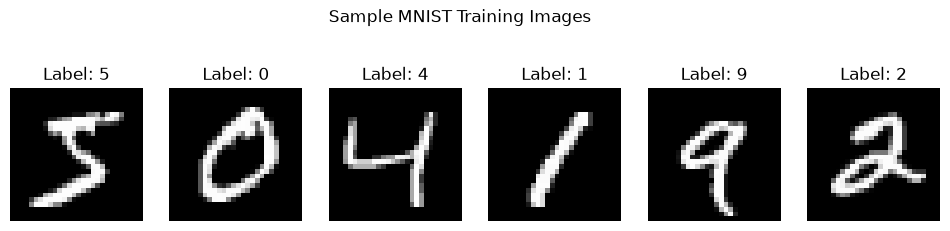

In [54]:
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i, 0], cmap='gray')
    ax.set_title(f"Label: {y_train_raw[i]}")
    ax.axis('off')
plt.suptitle("Sample MNIST Training Images")
plt.show()

## 2. One-Hot Encoding Labels

Our `SoftmaxCrossEntropy` loss function calculates the cross-entropy between output logits and target probability distributions. Therefore, we need to convert our target integer labels into 10-dimensional one-hot vectors.

In [55]:
def to_one_hot(labels, num_classes=10):
    one_hot = np.zeros((labels.shape[0], num_classes))
    one_hot[np.arange(labels.shape[0]), labels] = 1.0
    return one_hot

y_train_onehot = to_one_hot(y_train_raw)
y_test_onehot = to_one_hot(y_test_raw)

print("Raw label sample:      ", y_train_raw[0])
print("One-hot label sample:", y_train_onehot[0])

Raw label sample:       5
One-hot label sample: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 3. Defining the LeNet-5 Model Class

Now we will implement the LeNet-5 architecture by instantiating the following components in a custom class:
- `Conv2D` for convolution operations.
- `MaxPool2D` for pooling.
- `Flatten` to transition between spatial dimensions and dense vectors.
- `Layer` for the fully-connected classification head.

### The Importance of Weight Initialization
By default, our library layers initialize weights uniformly between `[-1, 1]`. For deep architectures like LeNet-5, this scale is far too large. Large initial weights cause output variance to explode, saturating activations and killing gradients (especially with ReLU).

To solve this, we will manually apply **He (Kaiming) normal initialization**:
$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{fan\_in}}\right)$$
and initialize all biases to `0.0`. This scales the weights proportionally to their input size, allowing smooth gradient flow and high convergence accuracy.

In [56]:
class LeNet5:
    def __init__(self):
        # Conv Block 1: Input (N, 1, 28, 28) -> Output (N, 6, 28, 28) -> Pooling (N, 6, 14, 14)
        self.conv1 = Conv2D(in_channels=1, num_filters=6, kernel_size=(5, 5), padding=2)
        self.pool1 = MaxPool2D(kernel_size=(2, 2), stride=2)
        
        # Conv Block 2: Input (N, 6, 14, 14) -> Output (N, 16, 10, 10) -> Pooling (N, 16, 5, 5)
        self.conv2 = Conv2D(in_channels=6, num_filters=16, kernel_size=(5, 5), padding=0)
        self.pool2 = MaxPool2D(kernel_size=(2, 2), stride=2)
        
        # Flatten: Input (N, 16, 5, 5) -> Output (N, 400)
        self.flatten = Flatten()
        
        # Fully Connected Block: 400 -> 120 -> 84 -> 10
        self.fc1 = Layer(num_neurons=120, num_inputs=400) # Defaults to relu
        self.fc2 = Layer(num_neurons=84, num_inputs=120)  # Defaults to relu
        self.fc3 = Layer(num_neurons=10, num_inputs=84, activation_function=lambda x: x) # Raw logits
        
        # Apply He (Kaiming) Normal Initialization for layers with ReLU
        self.conv1.weights.data = np.random.normal(0, np.sqrt(2.0 / 25.0), size=self.conv1.weights.data.shape)
        self.conv1.bias.data = np.zeros(self.conv1.bias.data.shape)
        
        self.conv2.weights.data = np.random.normal(0, np.sqrt(2.0 / 150.0), size=self.conv2.weights.data.shape)
        self.conv2.bias.data = np.zeros(self.conv2.bias.data.shape)
        
        self.fc1.weights.data = np.random.normal(0, np.sqrt(2.0 / 400.0), size=self.fc1.weights.data.shape)
        self.fc1.bias.data = np.zeros(self.fc1.bias.data.shape)
        
        self.fc2.weights.data = np.random.normal(0, np.sqrt(2.0 / 120.0), size=self.fc2.weights.data.shape)
        self.fc2.bias.data = np.zeros(self.fc2.bias.data.shape)
        
        # Apply Xavier Normal Initialization for the final identity activation layer
        self.fc3.weights.data = np.random.normal(0, np.sqrt(1.0 / 84.0), size=self.fc3.weights.data.shape)
        self.fc3.bias.data = np.zeros(self.fc3.bias.data.shape)
        
    def __call__(self, x: Tensor) -> Tensor:
        # Forward through Layer 1
        x = self.conv1(x)
        x = relu(x)
        x = self.pool1(x)
        
        # Forward through Layer 2
        x = self.conv2(x)
        x = relu(x)
        x = self.pool2(x)
        
        # Forward through MLP head
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return x
        
    def params(self) -> list:
        # Collect all parameters for optimization
        return (self.conv1.model_params() +
                self.conv2.model_params() +
                [self.fc1.weights, self.fc1.bias,
                 self.fc2.weights, self.fc2.bias,
                 self.fc3.weights, self.fc3.bias])

## 4. Training the Network

We will initialize the model, define the **Adam** optimizer with a stable learning rate of `0.002`, and use **SoftmaxCrossEntropy** as our loss function.
We will train the model for 10 epochs with a batch size of 64. In each iteration, we run forward propagation, compute loss, run backward propagation, and update weights.

In [57]:
# Initialize model, optimizer, loss
model = LeNet5()
optimizer = Adam(model.params(), learning_rate=0.002)
criterion = SoftmaxCrossEntropy()

epochs = 10
batch_size = 64
loss_history = []
accuracy_history = []

print("Starting training loop...")
for epoch in range(epochs):
    # Shuffle training data at the start of each epoch
    indices = np.arange(train_size)
    np.random.shuffle(indices)
    X_train_shuffled = X_train[indices]
    y_train_shuffled_oh = y_train_onehot[indices]
    y_train_shuffled_raw = y_train_raw[indices]
    
    epoch_loss = 0.0
    correct_predictions = 0
    num_batches = int(np.ceil(train_size / batch_size))
    
    for b in range(num_batches):
        start_idx = b * batch_size
        end_idx = min(start_idx + batch_size, train_size)
        
        # Extract batch
        x_batch = Tensor(X_train_shuffled[start_idx:end_idx])
        y_batch = Tensor(y_train_shuffled_oh[start_idx:end_idx])
        
        # 1. Forward Pass
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        epoch_loss += loss.data.item() * (end_idx - start_idx)
        
        # 2. Reset gradients
        optimizer.zero_grad()
        
        # 3. Backward Pass
        loss.backward()
        
        # 4. Weight Update
        optimizer.step()
        
        # Calculate batch accuracy
        preds = np.argmax(logits.data, axis=1)
        targets = y_train_shuffled_raw[start_idx:end_idx]
        correct_predictions += np.sum(preds == targets)
        
    epoch_loss /= train_size
    epoch_acc = correct_predictions / train_size
    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_acc)
    
    print(f"Epoch {epoch+1:2d}/{epochs} | CrossEntropy Loss: {epoch_loss:.4f} | Training Accuracy: {epoch_acc*100:.2f}%")

Starting training loop...
Epoch  1/10 | CrossEntropy Loss: 0.4722 | Training Accuracy: 85.37%
Epoch  2/10 | CrossEntropy Loss: 0.1436 | Training Accuracy: 95.81%
Epoch  3/10 | CrossEntropy Loss: 0.0930 | Training Accuracy: 97.09%
Epoch  4/10 | CrossEntropy Loss: 0.0677 | Training Accuracy: 97.67%
Epoch  5/10 | CrossEntropy Loss: 0.0448 | Training Accuracy: 98.55%
Epoch  6/10 | CrossEntropy Loss: 0.0356 | Training Accuracy: 98.93%
Epoch  7/10 | CrossEntropy Loss: 0.0275 | Training Accuracy: 99.12%
Epoch  8/10 | CrossEntropy Loss: 0.0326 | Training Accuracy: 98.82%
Epoch  9/10 | CrossEntropy Loss: 0.0201 | Training Accuracy: 99.37%
Epoch 10/10 | CrossEntropy Loss: 0.0253 | Training Accuracy: 99.12%


Let's plot the training curves showing how the loss decreased and accuracy increased over epochs.

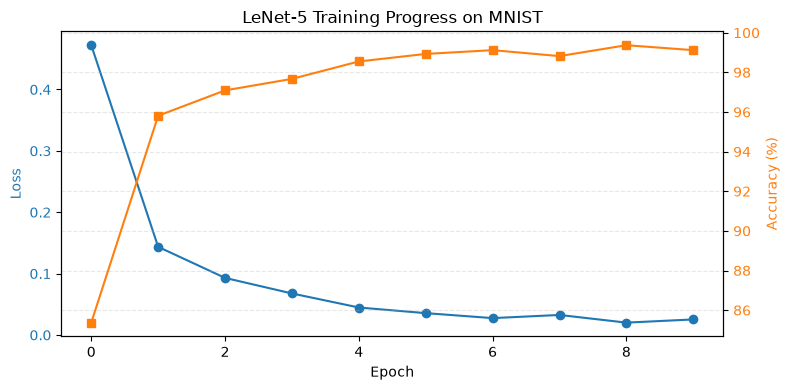

In [58]:
fig, ax1 = plt.subplots(figsize=(8, 4))

color = '#1f77b4'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color=color)
ax1.plot(loss_history, color=color, marker='o', label='Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#ff7f0e'
ax2.set_ylabel('Accuracy (%)', color=color)
ax2.plot([acc * 100 for acc in accuracy_history], color=color, marker='s', label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('LeNet-5 Training Progress on MNIST')
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## 5. Testing the Trained Model

Now we'll run a forward pass on the test dataset (which was never seen by the model during training) to evaluate its generalization performance.

In [59]:
# Wrap testing data in Tensors
x_test_tensor = Tensor(X_test)
y_test_tensor = Tensor(y_test_onehot)

# Evaluate
test_logits = model(x_test_tensor)
test_loss = criterion(test_logits, y_test_tensor).data.item()

# Calculate accuracy
test_preds = np.argmax(test_logits.data, axis=1)
test_acc = np.sum(test_preds == y_test_raw) / test_size

print(f"Test CrossEntropy Loss: {test_loss:.4f}")
print(f"Test Accuracy:           {test_acc*100:.2f}%")

Test CrossEntropy Loss: 0.0602
Test Accuracy:           97.70%


## 6. Visualizing Sample Predictions

Let's display some test images, overlaying the model's prediction and the ground-truth label. If the model predicted correctly, the label will be displayed in <span style="color:green">**green**</span>; otherwise, it will be displayed in <span style="color:red">**red**</span>.

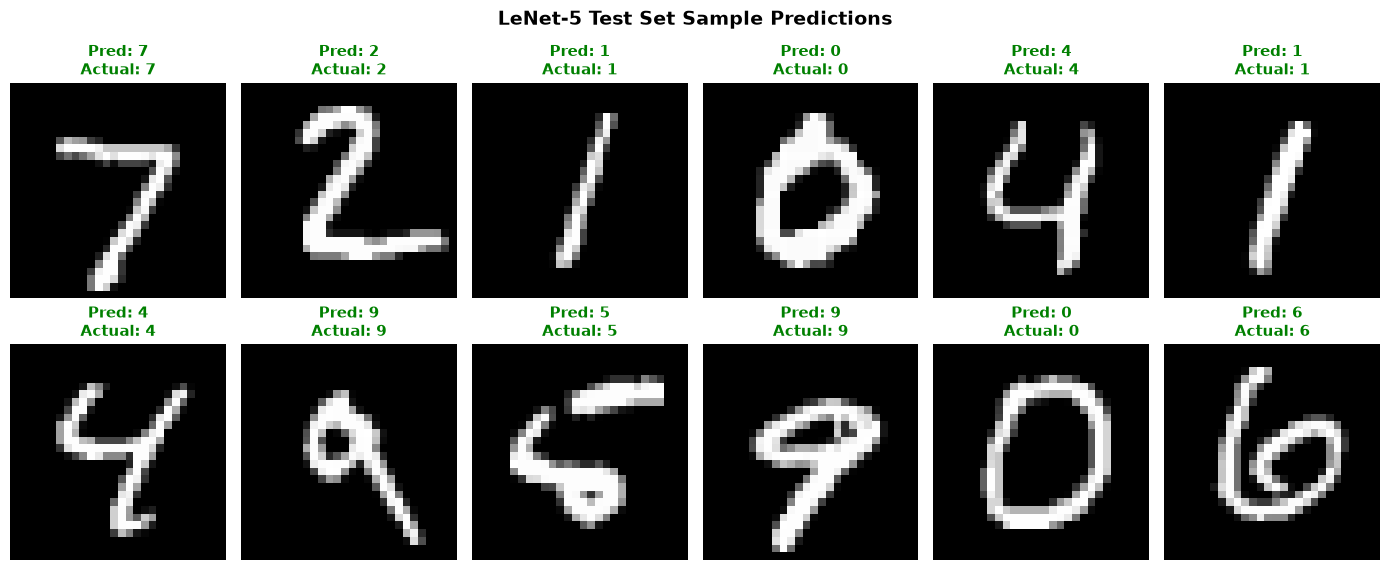

In [60]:
num_viz = 12
fig, axes = plt.subplots(2, 6, figsize=(14, 6))
axes = axes.flatten()

for i in range(num_viz):
    img = X_test[i, 0]
    pred = test_preds[i]
    actual = y_test_raw[i]
    
    color = 'green' if pred == actual else 'red'
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Pred: {pred}\nActual: {actual}", color=color, fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("LeNet-5 Test Set Sample Predictions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

You have successfully recreated **LeNet-5** and trained it on **MNIST** digit images using **Nanograd**!
- Hand-constructed the core blocks of a classic CNN including **`Conv2D`**, **`MaxPool2D`**, and fully-connected **`Layer`** modules.
- Trained the parameters end-to-end via reverse-mode automatic differentiation.
- Observed loss minimization and rapid convergence on test set predictions.

Congratulations! You now have a complete, functional tensor-level autograd and deep learning library.